# Fully connected autoencoder on MNIST

This notebook builds a simple **fully connected autoencoder** for handwritten digits from the MNIST dataset.

The goal of an autoencoder is:

- take an input image
- compress it into a smaller **latent representation**
- reconstruct the image from that compressed representation


## What this notebook will do

We will go step by step:

1. load the MNIST dataset
2. define an encoder and a decoder
3. train the model to reconstruct handwritten digits
4. plot the training loss
5. inspect the 2D latent space
6. compare input images and decoded output images
7. generate a new image from user-chosen latent coordinates

This notebook uses a **2-dimensional latent space**, so every 28x28 image is compressed to just two numbers.


In [1]:
# Import the libraries we need.
# torch is the main deep learning library.
# torchvision gives us the MNIST dataset and image transforms.
# matplotlib is used for plots.
# numpy is useful for numerical work.
import torch
import torchvision
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms


In [2]:
# Define a transform that converts each image to a PyTorch tensor.
# MNIST images are grayscale and have shape 28x28.
transform = transforms.ToTensor()

# Load the MNIST training and validation datasets.
# train=True gives the 60,000 training images.
# train=False gives the 10,000 test images.
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
valid_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders.
# The training loader uses shuffle=True so batches are mixed each epoch.
train_dl = torch.utils.data.DataLoader(train_dataset, batch_size=100, shuffle=True)
valid_dl = torch.utils.data.DataLoader(valid_dataset, batch_size=100)

print('Number of training images:', len(train_dataset))
print('Number of validation images:', len(valid_dataset))


Number of training images: 60000
Number of validation images: 10000


## Define the encoder and decoder

The encoder compresses a 28x28 image:

- 784 input pixels
- 128 hidden nodes
- 16 hidden nodes
- 2 latent coordinates

The decoder takes the 2 latent coordinates and tries to reconstruct the original 28x28 image.


In [3]:
class Encoder(nn.Module):
    def __init__(self, input_size=28 * 28, hidden_size1=128, hidden_size2=16, z_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, z_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


class Decoder(nn.Module):
    def __init__(self, output_size=28 * 28, hidden_size1=128, hidden_size2=16, z_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(z_dim, hidden_size2)
        self.fc2 = nn.Linear(hidden_size2, hidden_size1)
        self.fc3 = nn.Linear(hidden_size1, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x


In [4]:
# Select the device.
# If a GPU is available, PyTorch can use it automatically.
# Otherwise the code runs on the CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Selected device:', device)

# Create the encoder and decoder and move them to the selected device.
enc = Encoder().to(device)
dec = Decoder().to(device)


Selected device: cpu


In [5]:
# Define the loss function.
# MSELoss compares the reconstructed image to the original image.
loss_fn = nn.MSELoss()

# Use one optimizer for both encoder and decoder.
# This is simpler than using two separate optimizers in this teaching example.
optimizer = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=0.001)


## Train the autoencoder

The labels of the handwritten digits are **not** used for training.

This is **unsupervised learning**: the model learns only by trying to reconstruct its input.


In [6]:
# Set the number of training epochs.
num_epochs = 100
train_loss = []

# Loop over epochs.
for epoch in range(num_epochs):
    enc.train()
    dec.train()

    epoch_loss_sum = 0.0
    num_batches = 0

    # Each batch contains images and labels.
    # We ignore the labels here because autoencoders do not need them for training.
    for imgs, _ in train_dl:
        # Move images to the chosen device.
        imgs = imgs.to(device)

        # Flatten images from 28x28 to 784 values per image.
        imgs = imgs.flatten(1)

        # Encode then decode.
        latents = enc(imgs)
        output = dec(latents)

        # Compare reconstruction to original image.
        loss = loss_fn(output, imgs)

        # Standard gradient-descent step.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss_sum += loss.item()
        num_batches += 1

    # Store the average loss per batch for this epoch.
    average_epoch_loss = epoch_loss_sum / num_batches
    train_loss.append(average_epoch_loss)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}  average loss = {average_epoch_loss:.6f}')


Epoch   0  average loss = 0.066371
Epoch  10  average loss = 0.043309
Epoch  20  average loss = 0.040472
Epoch  30  average loss = 0.039314
Epoch  40  average loss = 0.038656
Epoch  50  average loss = 0.038118
Epoch  60  average loss = 0.037763
Epoch  70  average loss = 0.037418
Epoch  80  average loss = 0.037267
Epoch  90  average loss = 0.037061


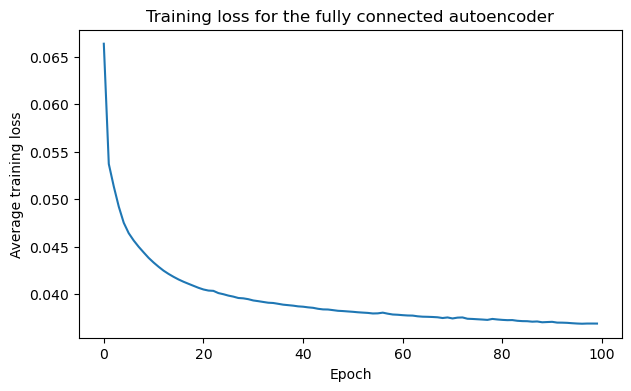

In [7]:
# Plot the training loss over epochs.
plt.figure(figsize=(7, 4))
plt.plot(train_loss)
plt.xlabel('Epoch')
plt.ylabel('Average training loss')
plt.title('Training loss for the fully connected autoencoder')
plt.show()


## Save the trained model

After training, we can save the learned weights to disk.
That lets us reuse the trained autoencoder in a second notebook without training it again.


In [8]:
# Create a folder for saved model files if it does not already exist.
from pathlib import Path

model_path = Path('saved_models/mnist_autoencoder_fc.pt')
model_path.parent.mkdir(parents=True, exist_ok=True)

# Save the encoder and decoder weights together in one file.
# We also store a few settings so a second notebook can rebuild the same network shape.
torch.save({
    'encoder_state_dict': enc.state_dict(),
    'decoder_state_dict': dec.state_dict(),
    'input_size': 28 * 28,
    'hidden_size1': 128,
    'hidden_size2': 16,
    'z_dim': 2,
}, model_path)

print(f'Saved trained model to {model_path.resolve()}')


Saved trained model to /Users/rolandg/Dropbox (Personal)/Lectures/2026/DataAnalysis_March2026/Notebooks/L9_JupyterNotebooks/saved_models/mnist_autoencoder_fc.pt


## Look at the latent space

Now we encode the training images into the 2D latent space.
Each image becomes one point with coordinates `(z1, z2)`.


In [9]:
values = None
all_labels = []

# Turn off gradient calculation because we are only evaluating the model.
enc.eval()
with torch.no_grad():
    for imgs, labels in train_dl:
        imgs = imgs.to(device)
        imgs = imgs.flatten(1)
        all_labels.extend(list(labels.numpy()))
        latents = enc(imgs)

        if values is None:
            values = latents.cpu()
        else:
            values = torch.vstack([values, latents.cpu()])

values = values.numpy()
all_labels = np.array(all_labels)


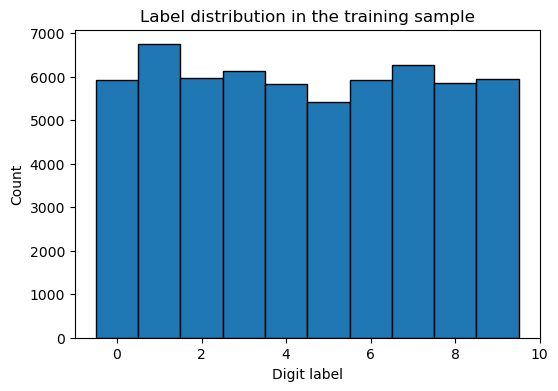

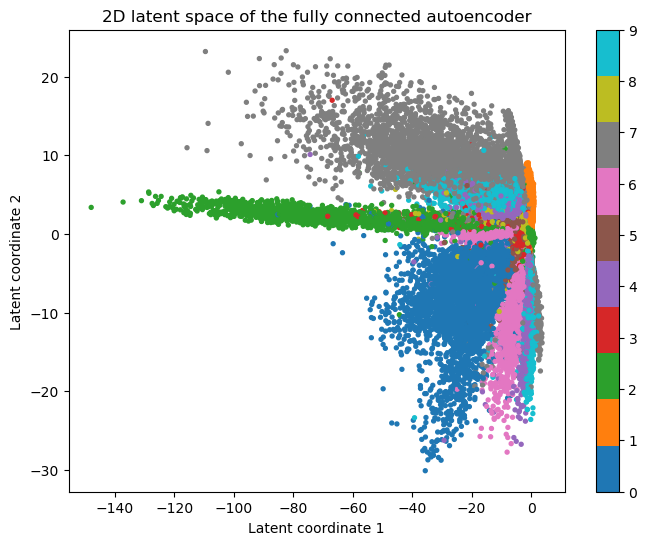

In [10]:
# Plot how many training examples we have for each digit label.
plt.figure(figsize=(6, 4))
plt.hist(all_labels, bins=np.arange(-0.5, 10.5, 1), edgecolor='black')
plt.xlabel('Digit label')
plt.ylabel('Count')
plt.title('Label distribution in the training sample')
plt.show()

# Plot the 2D latent space.
# Each point is one handwritten digit image, colored by its true label.
plt.figure(figsize=(8, 6))
pc = plt.scatter(values[:, 0], values[:, 1], c=all_labels, cmap='tab10', s=8)
plt.colorbar(pc)
plt.xlabel('Latent coordinate 1')
plt.ylabel('Latent coordinate 2')
plt.title('2D latent space of the fully connected autoencoder')
plt.show()


## Compare input images and reconstructed images

This lets us see how well the autoencoder reproduces the handwritten digits.


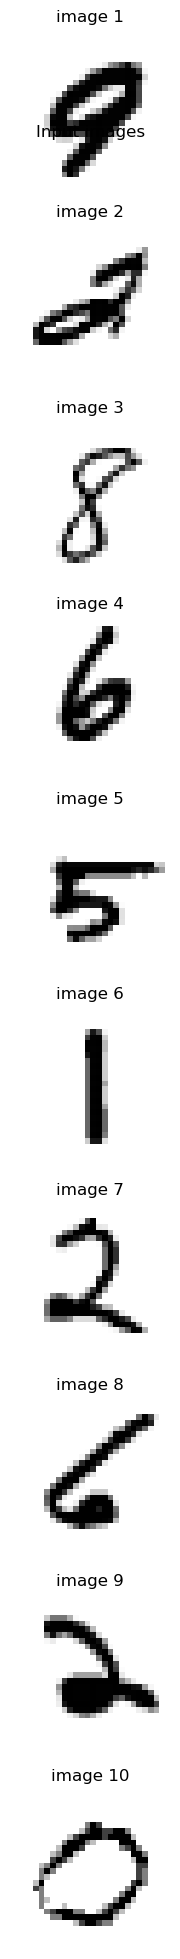

In [11]:
def plot_input_images(batch, n=10):
    fig, axes = plt.subplots(n, 1, figsize=(3, 2*n))
    fig.suptitle('Input images', y=0.92)
    for i in range(n):
        axes[i].imshow(batch[i].reshape(28, 28), cmap=plt.cm.gray_r, interpolation='nearest')
        axes[i].set_title(f'image {i+1}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()


# Get one batch of images from the training loader.
it = iter(train_dl)
xxx, lll = next(it)
plot_input_images(xxx, n=10)


In [12]:
# Map the batch of images into the 2D latent space.
xxx = xxx.to(device)
xxx_flat = xxx.flatten(1)

enc.eval()
with torch.no_grad():
    latent = enc(xxx_flat)

# Print the latent coordinates for images 1 to 10.
print(latent[1:11])


tensor([[-6.4005e+01,  3.3051e+00],
        [-1.8815e+00,  1.0555e+00],
        [-1.0460e+01, -5.9257e-02],
        [-5.7889e+00,  1.5216e+00],
        [-1.9263e-02,  5.0040e+00],
        [-5.5581e-01,  3.9708e-01],
        [-7.5109e+00,  9.1282e-01],
        [-1.0606e-01, -4.6020e-02],
        [-1.7823e+01, -8.1517e+00],
        [-2.0349e+01, -9.8163e+00]])


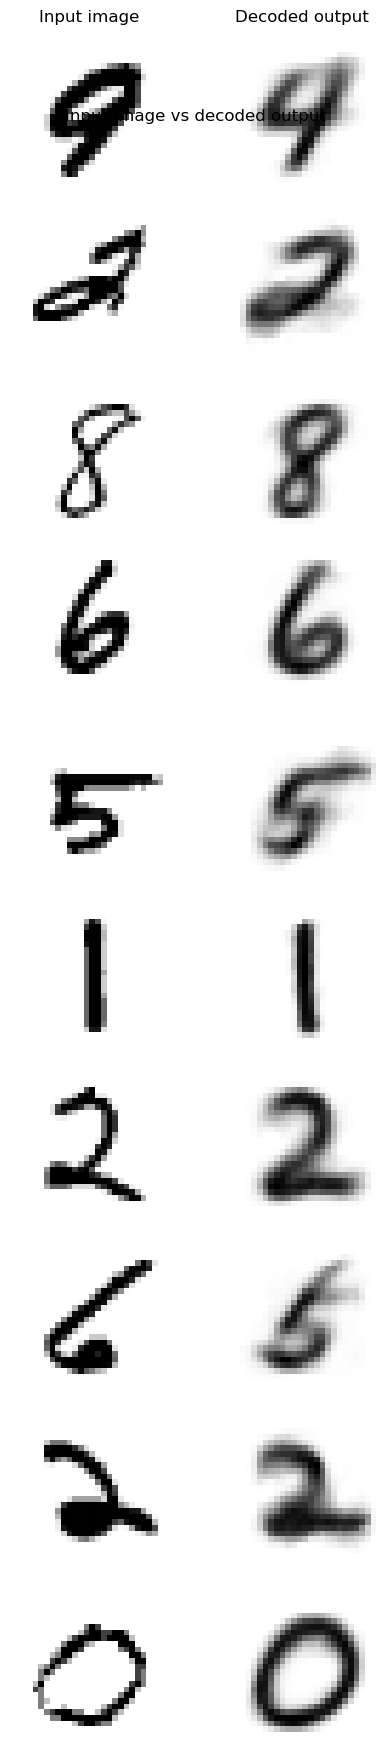

In [13]:
# Plot original images next to their decoded outputs.
fig, axes = plt.subplots(10, 2, figsize=(5, 18))
fig.suptitle('Input image vs decoded output', y=0.92)

dec.eval()
with torch.no_grad():
    for i in range(10):
        axes[i, 0].imshow(xxx[i].cpu().reshape(28, 28), cmap=plt.cm.gray_r, interpolation='nearest')
        axes[i, 0].axis('off')
        if i == 0:
            axes[i, 0].set_title('Input image')

        pred = dec(latent[i].unsqueeze(0)).cpu().reshape(28, 28)
        axes[i, 1].imshow(pred, cmap=plt.cm.gray_r, interpolation='nearest')
        axes[i, 1].axis('off')
        if i == 0:
            axes[i, 1].set_title('Decoded output')

plt.tight_layout()
plt.show()


## Generate an image from chosen latent coordinates

Because the latent space has only two dimensions, we can type in two coordinates and ask the decoder what image they correspond to.


Pick latent coordinate 1: 0
Pick latent coordinate 2: 20
Decode [0.0, 20.0] into a 28x28 image:


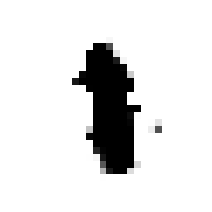

In [19]:
s = input('Pick latent coordinate 1: ')
x1 = float(s)
s = input('Pick latent coordinate 2: ')
x2 = float(s)
v = [x1, x2]

dec.eval()
with torch.no_grad():
    print(f'Decode {v} into a 28x28 image:')
    pred = dec(torch.tensor(v, dtype=torch.float32)[None, ...].to(device)).cpu()
    results = pred.reshape(28, 28)
    plt.figure(figsize=(2.5, 2.5))
    plt.imshow(results, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.axis('off')
    plt.show()
